In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

In [26]:
from pathlib import Path
import plotly.express as px

In [27]:
cwd = Path.cwd()
root = cwd if (cwd / "data").exists() else cwd.parent

candidates = [
    root / "data" / "mind@work" / "mental_health_dataset" / "Cleaned_remote_work.csv",
    root / "data" / "mind@work" / "mental heath dataset" / "Cleaned_remote_work.csv",  # legacy typo
]

data_file = next((p for p in candidates if p.exists()), None)
assert data_file is not None, f"Dataset not found. Checked:\n- " + "\n- ".join(map(str, candidates))
data_file

PosixPath('/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv')

In [28]:
df = pd.read_csv(data_file)
print(f"rows: {len(df):,} | cols: {df.shape[1]}")
df.head()

rows: 5,000 | cols: 19


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


# 1. Stress level as lable

In [29]:
# Target
target = "Stress_Level"

# Features (everything except target)
X = df.drop(columns=[target])
y = df[target]

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)   # High=0, Low=1, Medium=2 (check order with le.classes_)

# Encode features (categorical → one-hot)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
# Define 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics once (easy reuse)
scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Precision_macro": "precision_macro",
    "Recall_macro": "recall_macro",
}

def evaluate_model(model, X, y, cv=cv, scoring=scoring):
    """Run 5-fold CV and return results as a table."""
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    
    # Build summary table
    rows = []
    for metric in scoring.keys():
        mean = np.mean(cv_results[f"test_{metric}"])
        std = np.std(cv_results[f"test_{metric}"])
        rows.append({"Metric": metric, "Mean": mean, "Std": std})
    
    return pd.DataFrame(rows)

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Define 5 models
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "LinearSVC": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, random_state=42
    ),
}

In [32]:
# Run loop and collect results
results = []

for name, model in models.items():
    df_results = evaluate_model(model, X, y, cv=cv, scoring=scoring)
    df_results["Model"] = name
    results.append(df_results)

# Combine into one summary table
results_df = pd.concat(results, ignore_index=True)
results_df

,Metric,Mean,Std,Model
0,Accuracy,0.336200,0.013167,LogReg
1,F1_macro,0.335337,0.012966,LogReg
2,Precision_macro,0.335870,0.013065,LogReg
3,Recall_macro,0.335883,0.013119,LogReg
4,Accuracy,0.334800,0.012781,LinearSVC
5,F1_macro,0.333216,0.012251,LinearSVC
6,Precision_macro,0.334146,0.012356,LinearSVC
7,Recall_macro,0.334371,0.012683,LinearSVC
8,Accuracy,0.339000,0.007127,RandomForest
9,F1_macro,0.337826,0.006425,RandomForest


Age                                      0.089033
Hours_Worked_Per_Week                    0.088261
Years_of_Experience                      0.086987
Number_of_Virtual_Meetings               0.075383
Company_Support_for_Remote_Work          0.049174
Social_Isolation_Rating                  0.047695
Work_Life_Balance_Rating                 0.047067
Physical_Activity_Weekly                 0.019222
Access_to_Mental_Health_Resources_Yes    0.018804
Physical_Activity_No Activity            0.018403
dtype: float64


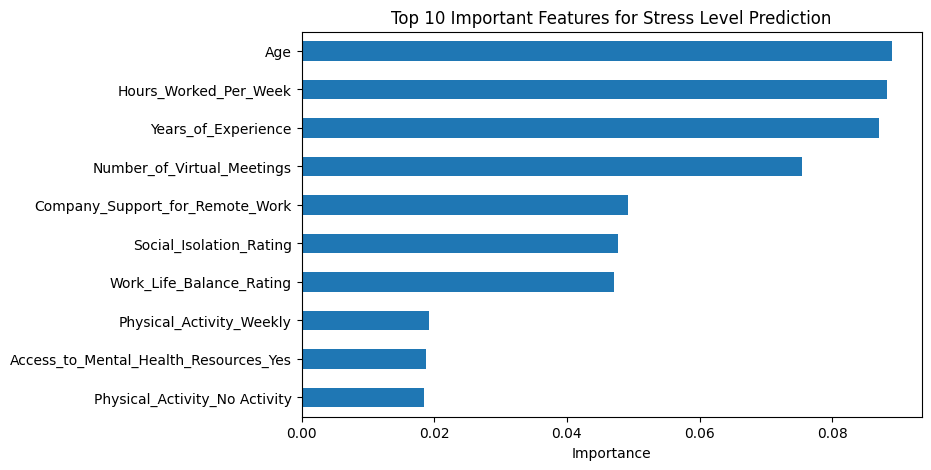

In [33]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Fit Random Forest on all features
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"   # because stress levels may be imbalanced
)
rf.fit(X, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Top 10
top10 = importances.sort_values(ascending=False).head(10)
print(top10)

# Optional: plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
top10.sort_values().plot(kind="barh")
plt.title("Top 10 Important Features for Stress Level Prediction")
plt.xlabel("Importance")
plt.show()

In [34]:
X_top = X[top10.index]   # or replace top10.index[:5] if you want only 5
print("Shape of reduced feature set:", X_top.shape)

def evaluate_model(model, X, y, cv=cv, scoring=scoring):
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    rows = []
    for metric in scoring.keys():
        rows.append({
            "Metric": metric,
            "Mean": np.mean(cv_results[f"test_{metric}"]),
            "Std":  np.std(cv_results[f"test_{metric}"]),
        })
    return pd.DataFrame(rows)

# --- Run loop ---
results = []
for name, model in models.items():
    df_res = evaluate_model(model, X_top, y, cv=cv, scoring=scoring)
    df_res["Model"] = name
    results.append(df_res)

results_df = pd.concat(results, ignore_index=True)
results_df

Shape of reduced feature set: (5000, 10)


,Metric,Mean,Std,Model
0,Accuracy,0.340600,0.014472,LogReg
1,F1_macro,0.337901,0.013659,LogReg
2,Precision_macro,0.340849,0.015305,LogReg
3,Recall_macro,0.340336,0.014465,LogReg
4,Accuracy,0.340600,0.015028,LinearSVC
5,F1_macro,0.336801,0.013882,LinearSVC
6,Precision_macro,0.340462,0.015773,LinearSVC
7,Recall_macro,0.340163,0.014984,LinearSVC
8,Accuracy,0.328800,0.013497,RandomForest
9,F1_macro,0.328260,0.013771,RandomForest


In [35]:
# --- 1) Build a binary target from Stress_Level ---
# Option A (strict): "High" = has_stress(1); "Medium"/"Low" = no_stress(0)
y_bin = (df["Stress_Level"] == "High").astype(int)

# Option B (lenient): "High" OR "Medium" = has_stress(1); "Low" = no_stress(0)
# y_bin = df["Stress_Level"].isin(["High", "Medium"]).astype(int)

print("Class balance (0=no stress, 1=has stress):")
print(y_bin.value_counts(normalize=True).rename("proportion"))

# --- 2) Features ---
# Use the same X you already prepared (one-hot encoded), or just keep top features you found
# X_bin = X[top10.index]         # if you want to use your top features only
X_bin = X                         # or use all features


Class balance (0=no stress, 1=has stress):
Stress_Level
0    0.6628
1    0.3372
Name: proportion, dtype: float64


In [36]:
# 2) Add binary-friendly metrics (keep your existing 'scoring' and extend it)
scoring_bin = {**scoring, "ROC_AUC": "roc_auc", "PR_AUC": "average_precision"}

# 3) Run your existing evaluation loop with the new target & metrics
results = []
for name, model in models.items():
    df_res = evaluate_model(model, X, y_bin, cv=cv, scoring=scoring_bin)
    df_res["Model"] = name
    results.append(df_res)

results_bin_df = pd.concat(results, ignore_index=True)
results_bin_df

,Metric,Mean,Std,Model
0,Accuracy,0.515400,0.021850,LogReg
1,F1_macro,0.500610,0.019001,LogReg
2,Precision_macro,0.512808,0.015959,LogReg
3,Recall_macro,0.514242,0.017702,LogReg
4,ROC_AUC,0.514581,0.024584,LogReg
5,PR_AUC,0.354226,0.016261,LogReg
6,Accuracy,0.514800,0.021226,LinearSVC
7,F1_macro,0.500409,0.018694,LinearSVC
8,Precision_macro,0.512906,0.015798,LinearSVC
9,Recall_macro,0.514371,0.017560,LinearSVC


,Importance
Hours_per_Age,0.067642
Age_WorkHours,0.066664
Meetings_per_YearExp,0.061491
Age,0.056586
Years_of_Experience,0.056508
Hours_Worked_Per_Week,0.055856
Balance_Meetings,0.053106
Number_of_Virtual_Meetings,0.043607
Wellbeing_Index,0.038729
Support_Index,0.029948


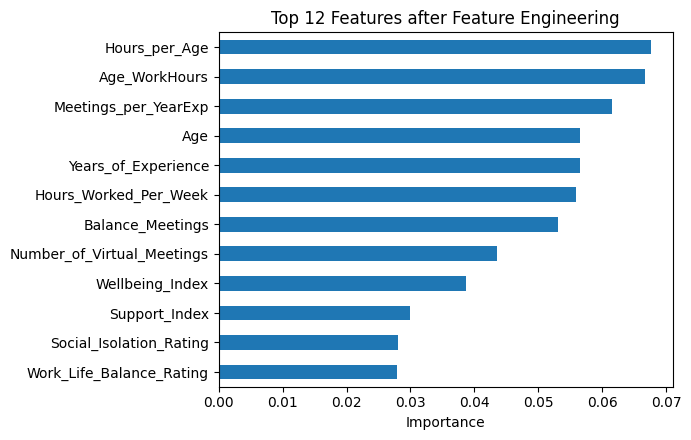

,Metric,Mean,Std,Model
0,Accuracy,0.343000,0.018730,LogReg (FE_top12)
1,F1_macro,0.341977,0.018680,LogReg (FE_top12)
2,Precision_macro,0.342486,0.018394,LogReg (FE_top12)
3,Recall_macro,0.342896,0.018666,LogReg (FE_top12)
4,Accuracy,0.340000,0.016769,LinearSVC (FE_top12)
5,F1_macro,0.338550,0.016592,LinearSVC (FE_top12)
6,Precision_macro,0.339273,0.016200,LinearSVC (FE_top12)
7,Recall_macro,0.339743,0.016697,LinearSVC (FE_top12)
8,Accuracy,0.332000,0.008124,RandomForest (FE_top12)
9,F1_macro,0.331357,0.008429,RandomForest (FE_top12)


In [37]:
# --- Feature engineering (safe to rerun) ---
X_base = X.copy()  # use whatever X you currently have
df_ = df.copy()

# 1) Interactions
fe = pd.DataFrame(index=df_.index)
fe["Age_WorkHours"]      = df_["Age"] * df_["Hours_Worked_Per_Week"]
fe["Balance_Meetings"]   = df_["Work_Life_Balance_Rating"] * df_["Number_of_Virtual_Meetings"]
fe["Isolation_x_NoRes"]  = df_["Social_Isolation_Rating"] * (df_["Access_to_Mental_Health_Resources"].map({"Yes":0,"No":1}).fillna(0))

# 2) Ratios / normalizations
fe["Meetings_per_YearExp"] = df_["Number_of_Virtual_Meetings"] / (df_["Years_of_Experience"] + 1)
fe["Hours_per_Age"]        = df_["Hours_Worked_Per_Week"] / (df_["Age"] + 1)

# 3) Bins / groupings
fe["Experience_Bin"] = pd.cut(
    df_["Years_of_Experience"],
    bins=[-1, 3, 10, 50], labels=["Junior", "Mid", "Senior"]
)

# 4) Domain composites (simple, interpretable)
# Higher is "better support / wellbeing"
fe["Support_Index"]  = (df_["Company_Support_for_Remote_Work"]
                        + df_["Access_to_Mental_Health_Resources"].map({"Yes":1,"No":0}).fillna(0))
fe["Wellbeing_Index"] = (df_["Work_Life_Balance_Rating"]
                         - df_["Social_Isolation_Rating"]
                         + df_["Sleep_Quality"].map({"Poor":0, "Average":1, "Good":2}).fillna(1))

# One-hot for newly created categorical only
fe = pd.get_dummies(fe, columns=["Experience_Bin"], drop_first=True)

# Combine with your current X and tidy up
X_fe = pd.concat([X_base, fe], axis=1)
X_fe = X_fe.replace([np.inf, -np.inf], np.nan).fillna(0)

# --- Rank features quickly with a RF and keep Top-K ---
from sklearn.ensemble import RandomForestClassifier

rf_ranker = RandomForestClassifier(
    n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1
)
# y_target: use y if present, else y_bin
y_target = y if "y" in locals() else y_bin

rf_ranker.fit(X_fe, y_target)
importances = pd.Series(rf_ranker.feature_importances_, index=X_fe.columns).sort_values(ascending=False)

topk = 12
top_features = importances.head(topk)
display(top_features.to_frame("Importance"))

# Optional: quick plot
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4.5))
top_features.sort_values().plot(kind="barh")
plt.title(f"Top {topk} Features after Feature Engineering")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- Re-run your existing CV loop with the selected features ---
X_sel = X_fe[top_features.index]

results = []
for name, model in models.items():   # uses your existing `models` dict
    df_res = evaluate_model(model, X_sel, y_target, cv=cv, scoring=scoring)  # uses your existing `evaluate_model`, `cv`, `scoring`
    df_res["Model"] = name + " (FE_top12)"
    results.append(df_res)

results_df = pd.concat(results, ignore_index=True)
results_df


# 2. Mental Health Condition as label

In [38]:
# --- Prep target and features ---
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# y: label-encoded Mental_Health_Condition
le = LabelEncoder()
y = le.fit_transform(df["Mental_Health_Condition"].fillna("Unknown"))
class_names = le.classes_  # keep for later reports if needed

# X: drop label and one-hot encode categoricals -> numeric matrix
X_raw = df.drop(columns=["Mental_Health_Condition"])
X = pd.get_dummies(X_raw, drop_first=True, dtype=float)  # works with your pipelines


In [39]:
# --- Run CV for the 5 models and collect results ---
results = []
for name, model in models.items():
    df_results = evaluate_model(model, X, y, cv=cv, scoring=scoring)
    df_results["Model"] = name
    results.append(df_results)

results_df = pd.concat(results, ignore_index=True)
results_df


,Metric,Mean,Std,Model
0,Accuracy,0.262200,0.005845,LogReg
1,F1_macro,0.262183,0.005441,LogReg
2,Precision_macro,0.263406,0.005371,LogReg
3,Recall_macro,0.262532,0.005795,LogReg
4,Accuracy,0.263600,0.004841,LinearSVC
5,F1_macro,0.263416,0.004291,LinearSVC
6,Precision_macro,0.264552,0.003749,LinearSVC
7,Recall_macro,0.263660,0.004820,LinearSVC
8,Accuracy,0.251800,0.009765,RandomForest
9,F1_macro,0.250160,0.010481,RandomForest


In [40]:
import pandas as pd

pd.Series(y).value_counts(normalize=True)

1    0.2560
0    0.2556
2    0.2492
3    0.2392
Name: proportion, dtype: float64

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Fit a quick model (using the same X, y)
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X, y)

# Extract feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Sort by importance
top_features = importances.sort_values(ascending=False)
print(top_features.head(10))

Hours_Worked_Per_Week                    0.088396
Years_of_Experience                      0.087221
Age                                      0.087100
Number_of_Virtual_Meetings               0.075446
Work_Life_Balance_Rating                 0.050822
Social_Isolation_Rating                  0.050697
Company_Support_for_Remote_Work          0.048060
Access_to_Mental_Health_Resources_Yes    0.021320
Sleep_Quality_Good                       0.019047
Productivity_Change_No Change            0.018938
dtype: float64


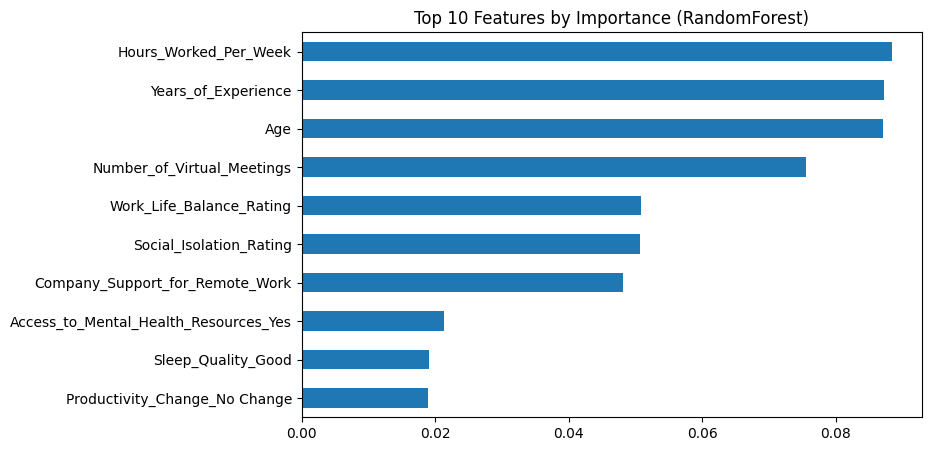

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
top_features.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Features by Importance (RandomForest)")
plt.show()

In [43]:
selected_features = top_features.head(5).index
X_reduced = X[selected_features]

In [44]:
results = []
for name, model in models.items():
    df_results = evaluate_model(model, X_reduced, y, cv=cv, scoring=scoring)
    df_results["Model"] = name + " (top5)"
    results.append(df_results)

# --- Combine results into one table ---
results_df = pd.concat(results, ignore_index=True)
results_df

,Metric,Mean,Std,Model
0,Accuracy,0.242400,0.011430,LogReg (top5)
1,F1_macro,0.237443,0.012276,LogReg (top5)
2,Precision_macro,0.242273,0.012947,LogReg (top5)
3,Recall_macro,0.241685,0.011529,LogReg (top5)
4,Accuracy,0.246800,0.010759,LinearSVC (top5)
5,F1_macro,0.238924,0.011323,LinearSVC (top5)
6,Precision_macro,0.244951,0.011441,LinearSVC (top5)
7,Recall_macro,0.245106,0.010843,LinearSVC (top5)
8,Accuracy,0.246800,0.013644,RandomForest (top5)
9,F1_macro,0.245531,0.013827,RandomForest (top5)


In [46]:
# --- 1) Binary target: Has mental health condition vs Unknown ---
y_bin = (df["Mental_Health_Condition"].fillna("No Condition") != "No Condition").astype(int)

# Quick check of balance
print("Class balance (0=no reported condition, 1=has condition):")
print(y_bin.value_counts(normalize=True).rename("proportion"))

# --- 2) Use top-5 features you identified earlier ---
top5 = [
    "Hours_Worked_Per_Week",
    "Years_of_Experience",
    "Age",
    "Number_of_Virtual_Meetings",
    "Work_Life_Balance_Rating",
]
X = df[top5].copy()

# If any of these happen to be non-numeric, make them numeric (most are already ints)
# X = pd.get_dummies(X, drop_first=True)  # (not needed if all are numeric)

# --- 3) 5-fold CV + metrics (add ROC-AUC & PR-AUC for binary) ---
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Precision_macro": "precision_macro",
    "Recall_macro": "recall_macro",
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision",   # area under PR curve (Average Precision)
}

def evaluate_model(model, X, y, cv=cv, scoring=scoring):
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    rows = []
    for metric in scoring.keys():
        rows.append({
            "Metric": metric,
            "Mean": np.mean(cv_results[f"test_{metric}"]),
            "Std":  np.std(cv_results[f"test_{metric}"]),
        })
    return pd.DataFrame(rows)

# --- 4) Models (with class_weight='balanced' where available) ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

scaler = StandardScaler(with_mean=False)  # harmless for pure-numeric; keeps sparse compatibility

models = {
    "LogReg (bin)": Pipeline([
        ("scaler", scaler),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=None))
    ]),
    "LinearSVC (bin)": Pipeline([
        ("scaler", scaler),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),
    "RandomForest (bin)": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced_subsample"
    ),
    "GradientBoosting (bin)": GradientBoostingClassifier(random_state=42),
    "AdaBoost (bin)": AdaBoostClassifier(n_estimators=300, random_state=42),
}

# --- 5) Run CV for each model and combine into a tidy table ---
results = []
for name, model in models.items():
    df_res = evaluate_model(model, X, y_bin, cv=cv, scoring=scoring)
    df_res["Model"] = name
    results.append(df_res)

results_df = pd.concat(results, ignore_index=True)
results_df


Class balance (0=no reported condition, 1=has condition):
Mental_Health_Condition
1    0.7608
0    0.2392
Name: proportion, dtype: float64


/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

,Metric,Mean,Std,Model
0,Accuracy,0.489800,0.006794,LogReg (bin)
1,F1_macro,0.451617,0.007094,LogReg (bin)
2,Precision_macro,0.488230,0.006713,LogReg (bin)
3,Recall_macro,0.483829,0.009231,LogReg (bin)
4,ROC_AUC,0.477542,0.009127,LogReg (bin)
5,PR_AUC,0.751550,0.005754,LogReg (bin)
6,Accuracy,0.489800,0.006911,LinearSVC (bin)
7,F1_macro,0.451616,0.007134,LinearSVC (bin)
8,Precision_macro,0.488229,0.006718,LinearSVC (bin)
9,Recall_macro,0.483829,0.009237,LinearSVC (bin)


Right now, predicting four distinct stress levels from the available features seems intrinsically noisy. The best model’s ~0.35 accuracy shows some signal but not enough for confident per-person classification. The pattern of mistakes (heavy confusion among neighboring classes) and the improvement when using all features indicate that the phenomenon is gradual/ordinal and multifactorial. Recasting the task as ordinal (or simplifying to fewer categories) and investing in feature engineering + tuning will likely yield the most meaningful lift.

Classification with mental health condition binary looks more potential with higher accuracy than stress as label